## Enunciado:
Encontre um conjunto de dados envolvendo um Fator e um Bloco. Faça a análise completa destes dados. 
Escreva o seu relatorio em PDF. Esteja preparado para apresentá-lo em sala de aula

---

Conjunto de dados escolhido: Problem **4-7** do livro "Design and Analysis of Experiments"(5th Edition), Douglas C. Montgomery,

# Delineamento em Blocos Aleatorizado

## Contextualização do Problema

Uma empresa fabricante de ligas-mestre de alumínio produz refinadores de grão em forma de lingotes. O processo produtivo é realizado em quatro fornos diferentes. Cada forno possui características operacionais próprias, o que pode influenciar o tamanho de grão do produto final.

Os engenheiros de processo suspeitam que a **taxa de agitação** do material durante a produção afeta o tamanho de grão obtido. Entretanto, como os fornos apresentam diferenças naturais entre si, eles são tratados como uma fonte de variabilidade não controlável no experimento, ou seja, como **blocos**.

Para investigar o efeito da taxa de agitação sobre o tamanho de grão, foi conduzido um experimento utilizando um **Delineamento em Blocos Aleatorizados  (DBA)**.

---

# Objetivo

Avaliar se diferentes taxas de agitação influenciam significativamente o tamanho de grão do produto, controlando a variabilidade causada pelos diferentes fornos utilizados no processo.

---

# Estrutura Experimental

- **Fator (Tratamento):** Taxa de agitação (rpm)
- **Níveis do fator:** 5, 10, 15 e 20 rpm
- **Blocos:** Fornos (1, 2, 3 e 4)
- **Variável resposta:** Tamanho de grão

---

# Dados do Experimento

| Taxa de Agitação (rpm) | Forno 1 | Forno 2 | Forno 3 | Forno 4 |
|------------------------|----------|----------|----------|----------|
| 5                      | 8        | 4        | 5        | 6        |
| 10                     | 14       | 5        | 6        | 9        |
| 15                     | 14       | 6        | 9        | 2        |
| 20                     | 17       | 9        | 3        | 6        |

---

# Software Utilizado

As análises serão realizadas no software **R**, utilizando funções da linguagem base para ajuste do modelo ANOVA e análise diagnóstica.

## 1. Análise completa dos dados

#### Modelo

Nesse caso, o modelo utilizado para o DBA é:


$Y_{ij} = \mu + \tau_i + \beta_j + \varepsilon_{ij}$


onde:

- $Y_{ij}$: observação do tratamento $i$ no bloco $j$
- $\mu$: média geral
- $\tau_i$: efeito do tratamento (taxa de agitação)
- $\beta_j$: efeito do bloco (forno)
- $\varepsilon_{ij}$: erro aleatório experimental

---

# Hipóteses que podem ser feitas

### Para os tratamentos (taxa de agitação) (**Prioridade**)

$
H_0: \tau_1 = \tau_2 = \tau_3 = \tau_4 = 0
$

$
H_1: \text{Pelo menos uma taxa de agitação apresenta efeito diferente}
$

### Para os blocos (fornos) (não importa nessa situação)

$
H_0: \beta_1 = \beta_2 = \beta_3 = \beta_4 = 0
$

$
H_1: \text{Pelo menos um forno apresenta efeito diferente}
$

---

# Metodologia de Análise

A análise será realizada por meio de:

1. Estatística descritiva;
2. Análise de variância (ANOVA);
3. Verificação dos pressupostos:
   - normalidade dos resíduos;
   - homogeneidade das variâncias;
4. Comparação múltipla de médias (Teste de Tukey);
5. Construção de gráficos exploratórios.

## 1. Análise completa dos dados

#### Modelo

Nesse caso, o modelo utilizado para o DBA é:


$Y_{ij} = \mu + \tau_i + \beta_j + \varepsilon_{ij}$


onde:

- $Y_{ij}$: observação do tratamento $i$ no bloco $j$
- $\mu$: média geral
- $\tau_i$: efeito do tratamento (taxa de agitação)
- $\beta_j$: efeito do bloco (forno)
- $\varepsilon_{ij}$: erro aleatório experimental

---

# Hipóteses que podem ser feitas

### Para os tratamentos (taxa de agitação) (**Prioridade**)

$
H_0: \tau_1 = \tau_2 = \tau_3 = \tau_4 = 0
$

$
H_1: \text{Pelo menos uma taxa de agitação apresenta efeito diferente}
$

### Para os blocos (fornos) (não importa nessa situação)

$
H_0: \beta_1 = \beta_2 = \beta_3 = \beta_4 = 0
$

$
H_1: \text{Pelo menos um forno apresenta efeito diferente}
$

---

# Metodologia de Análise

A análise será realizada por meio de:

1. Estatística descritiva;
2. Verificação dos pressupostos:
   - normalidade dos resíduos;
   - homogeneidade das variâncias;
3. Análise de variância (ANOVA);
4. Comparação múltipla de médias (Teste de Tukey);

In [1]:
# Matriz fornecida
dados_mat <- matrix(c(8, 14, 14, 17,   # Forno 1 (5,10,15,20 rpm)
                      4, 5, 6, 9,      # Forno 2
                      5, 6, 9, 3,      # Forno 3
                      6, 9, 2, 6),     # Forno 4
                    nrow = 4, byrow = FALSE)
# Converter para data.frame longo
library(tidyr)
library(dplyr)

dados <- data.frame(
  Taxa = rep(c(5, 10, 15, 20), times = 4),
  Forno = rep(1:4, each = 4),
  Tamanho = as.vector(dados_mat)
)
# estrutura
head(dados)
# tratamentos e blocos como fatores
dados$Taxa <- as.factor(dados$Taxa)
dados$Forno <- as.factor(dados$Forno)
# análise descritiva exploratória
dados %>%
  group_by(Taxa) %>%
  summarise(Media = mean(Tamanho), DP = sd(Tamanho), n = n())
dados %>%
  group_by(Forno) %>%
  summarise(Media = mean(Tamanho), DP = sd(Tamanho))


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




,Taxa,Forno,Tamanho
,<dbl>,<int>,<dbl>
1,5,1,8
2,10,1,14
3,15,1,14
4,20,1,17
5,5,2,4
6,10,2,5


Taxa,Media,DP,n
<fct>,<dbl>,<dbl>,<int>
5,5.75,1.707825,4
10,8.50,4.041452,4
15,7.75,5.057997,4
20,8.75,6.020797,4


Forno,Media,DP
<fct>,<dbl>,<dbl>
1,13.25,3.774917
2,6.00,2.160247
3,5.75,2.500000
4,5.75,2.872281


#### 1.1 Estatística descritiva

As estatísticas descritivas exploratórias:

| Taxa  | Media | DP | n |
|-------|--------|---------|---|
| 5  | 5.75 | 1.707825 | 4 |
| 10 | 8.50 | 4.041452 | 4 |
| 15 | 7.75 | 5.057997 | 4 |
| 20 | 8.75 | 6.020797 | 4 |

---

| Forno | Media | DP | n |
|--------|--------|---------|---------|
| 1 | 13.25 | 3.774917 | 4 |
| 2 | 6.00  | 2.160247 | 4|
| 3 | 5.75  | 2.500000 | 4|
| 4 | 5.75  | 2.872281 | 4|

![gráfico de interação e boxplots por tratamento.png](1_1_grafico_interacao_boxplot.png)

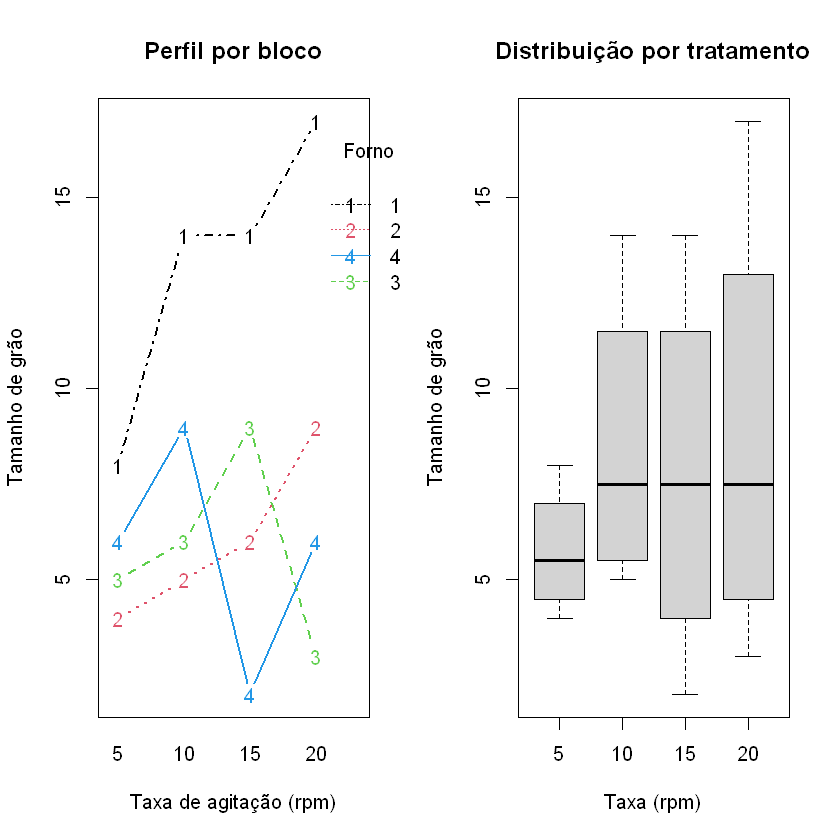

In [2]:
par(mfrow = c(1,2))
# gráfico de interação (note que é DBA aditivo, sem replicação)
interaction.plot(dados$Taxa, dados$Forno, dados$Tamanho,
                 type = "b", col = 1:4, lwd = 2,
                 xlab = "Taxa de agitação (rpm)", ylab = "Tamanho de grão",
                 trace.label = "Forno", main = "Perfil por bloco")

# boxplots por tratamento
boxplot(Tamanho ~ Taxa, data = dados, 
        xlab = "Taxa (rpm)", ylab = "Tamanho de grão",
        main = "Distribuição por tratamento")

par(mfrow = c(1,1))


	Shapiro-Wilk normality test

data:  residuos_DBA
W = 0.9301, p-value = 0.2447


Carregando pacotes exigidos: carData


Attaching package: 'car'


The following object is masked from 'package:dplyr':

    recode




,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,3,0.993994,0.4287067
,12,NA,NA



	Bartlett test of homogeneity of variances

data:  Tamanho by Taxa
Bartlett's K-squared = 3.5316, df = 3, p-value = 0.3167


            Df Sum Sq Mean Sq F value Pr(>F)  
Taxa         3  22.19    7.40   0.853 0.4995  
Forno        3 165.19   55.06   6.348 0.0133 *
Residuals    9  78.06    8.67                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

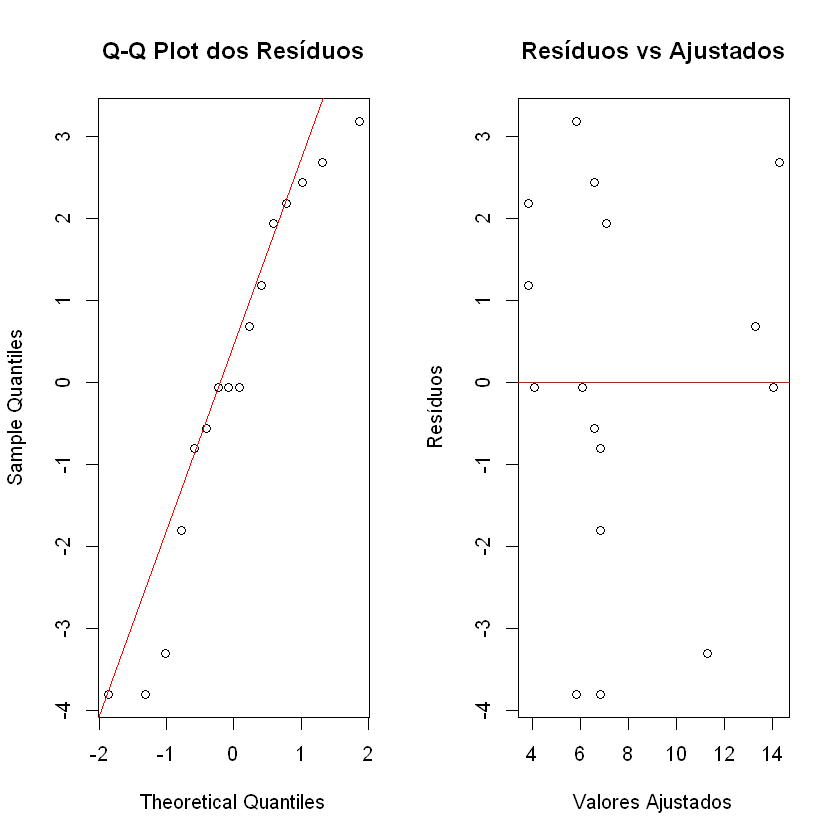

In [3]:
# ajuste do modelo AnoVa aditivo
modelo_anova_DBA <- aov(Tamanho ~ Taxa + Forno, data = dados)

# verificação dos pressupostos
residuos_DBA <- residuals(modelo_anova_DBA)
ajustados_DBA <- fitted(modelo_anova_DBA)

# Normalidade
shapiro.test(residuos_DBA)   # aceita normalidade e p > 0.05, mas note que n pequeno mas mesmo assim o teste é robusto
# Homocedasticidade - teste de Levene (car::leveneTest)
library(car)
leveneTest(Tamanho ~ Taxa, data = dados)
bartlett.test(Tamanho ~ Taxa, data = dados)
# gráficos de diagnóstico
par(mfrow = c(1,2))

qqnorm(residuos_DBA, main = "Q-Q Plot dos Resíduos")
qqline(residuos_DBA, col = "red")
plot(ajustados_DBA, residuos_DBA,
     xlab = "Valores Ajustados", ylab = "Resíduos",
     main = "Resíduos vs Ajustados")
abline(h = 0, col = "red")

par(mfrow = c(1,1))

summary(modelo_anova_DBA)

#### 1.2 Veificando os pressupostos

| | Normalidade(Shapiro-Wilk) | Homocedasticidade (Bartlett) | Homocedasticidade (Levene) |
|-------|--------|---------|---|
|Valor-p dos testes| 0.24| 0.31|0.42|

![gráficos de diagnostico](1_2_diagnostico_residuoo.png)

Os pressupostos não são violados, pelos testes feitos acima e os gráficos.

---

#### 1.3 Resultados da AnoVa


|           | Df| Sum Sq |Mean Sq| F value| Pr(>F) | 
|-----------|-------|--------|---------|---|--------|
|Taxa       |  3 | 22.19  |  7.40  | 0.853 |0.4995  
|Forno      |  3 |165.19  | 55.06  | 6.348 | 0.0133 
|Residuals  | 9 | 78.06   | 8.67  |


A estatística $F_0$ de 0.853 não é significativa e o valor-p = 0.4995 é grande, então a
hipótese nula não é rejeitada. Os dados não oferecem evidências suficientes para concluir que a taxa de agitação apresenta efeito diferente no tamanho do grão produzido.

Consequentemente, como o fator de interesse (efeito de taxa de agitação) não foi significativo, não há necessidade de fazer comparações múltiplas (nem Bonferroni nem Tukey.)

*Note que o efeito do bloco(forno) foi significativo para o tamanho do grão, uma comparação múltipla pode ser feita, mas não é o interesse da situação*

---

## 2. Análise completa dos dados

#### Modelo de regressão

Nesse caso, O modelo de regressão com blocos pode ser representado por:

$Y_{ij} = \mu + \tau_1*X_1 + \tau_2*X_2+ \tau_3*X_3 + \beta_1*Z_1 +\beta_1*Z_2 + \beta_1*Z_3 + \varepsilon_{ij}$

*Set to zero*: $\tau_4 = \beta_4= 0$

em que  

* $Y_{ij}$: tamanho de grão observado para a taxa de agitação $i$ no forno $j$;
* $X_i = 1$ se a observação for submetido ao $i^{th}$ nível, e $X_i = 0$ caso contrário (primeiro nível: taxa de 5 rpm, segundo: 10 rpm assim por diante)
* $Z_j = 1$ se a observação for submetido ao $j^{th}$ bloco, e $Z_j = 0$ caso contrário
* $\mu$: média geral do experimento;
* $\tau_i$: efeito da taxa de agitação;
* $\beta_j$: efeito do bloco (forno);
* $\varepsilon_{ij}$: erro aleatório associado à observação.

Assume-se que:

$
\varepsilon_{ij} \sim N(0, \sigma^2)
$

ou seja, os erros são independentes, normalmente distribuídos e com variância constante.

---

# Hipóteses que podem ser feitas

## Efeito da taxa de agitação  (Hipótese de Interesse, Prioridade)

$
H_0: \tau_1 = \tau_2 = \tau_3 = \tau_4 = 0
$

$
H_1: \text{Pelo menos uma taxa de agitação afeta o tamanho de grão}
$

## Efeito dos fornos/blocos (não é o Interesse, não importa, ignora)

$
H_0: \beta_1 = \beta_2 = \beta_3 = \beta_4 = 0
$

$
H_1: \text{Pelo menos um forno apresenta efeito significativo}
$

---

# Metodologia de Análise

A análise será realizada por meio de:

1. Organização e exploração descritiva dos dados;
2. Ajuste do modelo de regressão com blocos;
3. Verificação dos pressupostos:
   - normalidade dos resíduos;
   - homocedasticidade;
   - independência dos erros;
4. Construção de gráficos diagnósticos.   
5. Análise de variância (ANOVA) do modelo;
6. Interpretação dos coeficientes do modelo;


---


In [4]:
library(dplyr)
# criando variaveis dummies manualmente
dados_dummy <- dados %>%
  mutate(
    Taxa5 = as.numeric(Taxa == 5),
    Taxa10 = as.numeric(Taxa == 10),
    Taxa15 = as.numeric(Taxa == 15),
    Forno1 = as.numeric(Forno == 1),
    Forno2 = as.numeric(Forno == 2),
    Forno3 = as.numeric(Forno == 3)
  )

## 2.1 Análise descritiva

As estatísticas descritivas exploratórias (são as mesmas):

| Taxa  | Media | DP | n |
|-------|--------|---------|---|
| 5  | 5.75 | 1.707825 | 4 |
| 10 | 8.50 | 4.041452 | 4 |
| 15 | 7.75 | 5.057997 | 4 |
| 20 | 8.75 | 6.020797 | 4 |

---

| Forno | Media | DP | n |
|--------|--------|---------|---------|
| 1 | 13.25 | 3.774917 | 4 |
| 2 | 6.00  | 2.160247 | 4|
| 3 | 5.75  | 2.500000 | 4|
| 4 | 5.75  | 2.872281 | 4|

## 2.2 Verificação dos pressupostos

Os resíduos do modelo de regressão devem atender aos pressupostos de normalidade, homocedasticidade e independência (já garantida pela aleatorização). 

Abaixo são apresentados os testes estatísticos e os gráficos de diagnóstico.

| | Normalidade(Shapiro-Wilk) | Homocedasticidade (Breusch-Pagan) |
|-------|--------|---------|
|Valor-p dos testes| 0.24| 0.64|

![gráficos de diagnostico](1_2_diagnostico_residuoo.png)

Os pressupostos não são violados, pelos testes feitos acima e os gráficos.

---


	Shapiro-Wilk normality test

data:  residuos_dummy
W = 0.9301, p-value = 0.2447


Carregando pacotes exigidos: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric





	studentized Breusch-Pagan test

data:  mod_reg_dummy
BP = 4.2259, df = 6, p-value = 0.6461


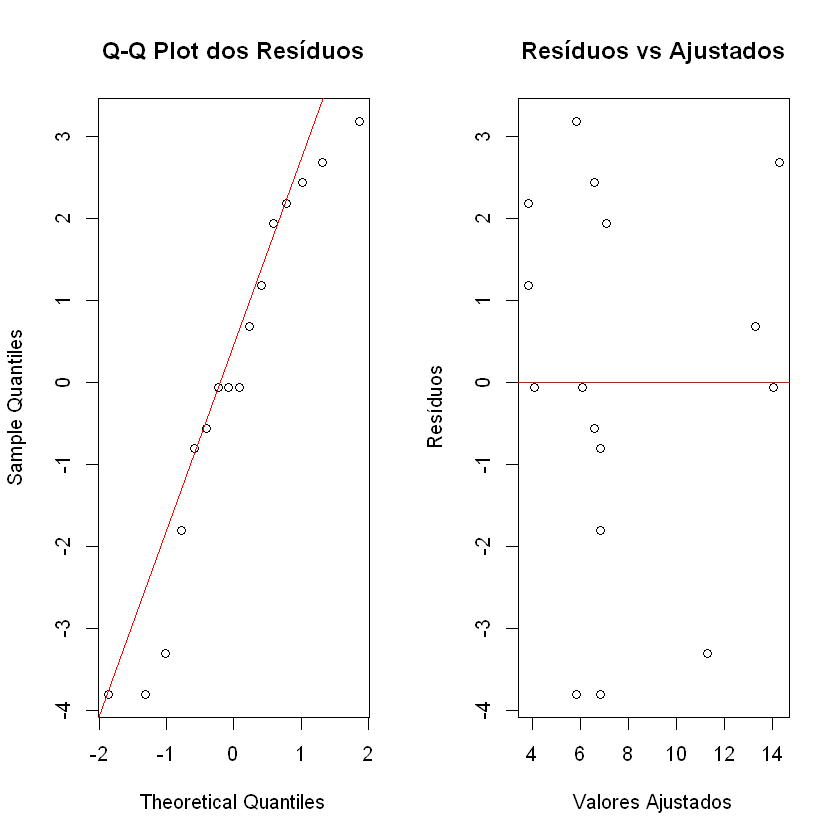

In [5]:
# ajuste do modelo de regressão
mod_reg_dummy <- lm(Tamanho ~ Taxa5 + Taxa10 + Taxa15 + Forno1 + Forno2 + Forno3, data = dados_dummy)

# extrair resíduos e valores ajustados
residuos_dummy <- residuals(mod_reg_dummy)
ajustados_dummy <- fitted(mod_reg_dummy)

# 1. Gráfico Q-Q para normalidade e # 2. homocedasticidade: gráfico resíduos vs ajustados

# Teste de Shapiro-Wilk
shapiro.test(residuos_dummy)
par(mfrow = c(1,2))
qqnorm(residuos_dummy, main = "Q-Q Plot dos Resíduos")
qqline(residuos_dummy, col = "red")
plot(ajustados_dummy, residuos_dummy,
     xlab = "Valores Ajustados", ylab = "Resíduos",
     main = "Resíduos vs Ajustados")
abline(h = 0, col = "red")
par(mfrow = c(1,1))

# Teste de Breusch-Pagan
library(lmtest)
bptest(mod_reg_dummy)  # H0: homocedasticidade

## 2.3 Tabela ANOVA

Tabela ANOVA do modelo completo: 

| Fonte     | Df | Sum Sq | Mean Sq | F value | Pr(>F) |
|------------|----|---------|----------|----------|---------|
| Taxa5 ($\tau_1$)     | 1  | 20.021  | 20.021   | 2.308    | 0.163 |
| Taxa10 ($\tau_2$)    | 1  | 0.167   | 0.167    | 0.019    | 0.893 |
| Taxa15 ($\tau_3$)    | 1  | 2.000   | 2.000    | 0.231    | 0.643 |
| Forno1 ($\beta_1$)    | 1  | 165.021 | 165.021  | 19.026   | 0.002 |
| Forno2 ($\beta_2$)    | 1  | 0.167   | 0.167    | 0.019    | 0.893 |
| Forno3 ($\beta_3$)    | 1  | 0.000   | 0.000    | 0.000    | 1.000 |
| Residuals  | 9  | 78.062  | 8.674    | NA       | NA |

Podemos tirar as mesmas conclusões:

As estatísticas $F_0$ do fator não são significativo e os valores-p são grandes, então a
hipótese nula não é rejeitada. Os dados não oferecem evidências suficientes para concluir que a taxa de agitação apresenta efeito diferente no tamanho do grão produzido.

Consequentemente, como o fator de interesse (efeito de taxa de agitação) não foi significativo, não há necessidade de fazer comparações múltiplas (nem Bonferroni nem Tukey).

*Note que o efeito do bloco(forno) foi significativo para o tamanho do grão, uma comparação múltipla pode ser feita, mas não é o interesse da situação*

In [6]:
# tabela ANOVA do modelo de regressão
anova(mod_reg_dummy)

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Taxa5,1,2.002083e+01,2.002083e+01,2.308247e+00,0.16300750
Taxa10,1,1.666667e-01,1.666667e-01,1.921537e-02,0.89280291
Taxa15,1,2.000000e+00,2.000000e+00,2.305845e-01,0.64254667
Forno1,1,1.650208e+02,1.650208e+02,1.902562e+01,0.00181859
Forno2,1,1.666667e-01,1.666667e-01,1.921537e-02,0.89280291
Forno3,1,1.232595e-32,1.232595e-32,1.421086e-33,1.00000000
Residuals,9,7.806250e+01,8.673611e+00,NA,NA


#### 2.Extra.1

Fazendo teste F-parcial (modelo reduzido sem os $\tau_i$, mantendo apenas os $\beta_j$ vs. modelo completo; e modelo reduzido sem os $\beta_j$, mantendo apenas os $\tau_i$ vs. modelo completo ):

| Fonte     | Df | Sum Sq | Mean Sq | F value | Pr(>F) |
|------------|----|---------|----------|----------|---------|
| Taxa de agitação    | 3  | 22.19  | 7.4   | 0.853    | 0.499 |
| Forno    | 3  | 165.19   | 55.06    | 6.348    | 0.0133 |
|Resíduos | 9| 78.06| 8.67 |

Assim, pode-se dizer que:

* Para "Taxa de agitação": valor-p = 0.499 é grande, isso significa que remover “Taxa de agitação” não piora o ajuste do modelo, mesmo mantendo “Forno”.

* Para “Forno”: valor-p = 0.01 é  pequeno, isso significa que remover “Forno” piora fortemente o ajuste do modelo, mesmo mantendo "Taxa de agitação".

Resumindo: dá pra tirar a mesma conclusão de antes: o fator de interesse (efeito de taxa de agitação) não foi significativo.

In [7]:
# Comparação com a ANOVA do modelo clássico (deve ser idêntica)
mod_anova <- aov(Tamanho ~ Taxa + Forno, data = dados)
summary(mod_anova)

            Df Sum Sq Mean Sq F value Pr(>F)  
Taxa         3  22.19    7.40   0.853 0.4995  
Forno        3 165.19   55.06   6.348 0.0133 *
Residuals    9  78.06    8.67                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

#### 2.Extra.2

Pode-se calcular a matriz chapéu *H*,

mas o delineamento é balanceado e todas as combinações tratamento-bloco estão presentes, a matriz X tem certa simetria, e os $h_{ii}$ ​podem ser iguais para todas as observações (aproximadamente $p/n=7/16=0,4375$). Nesse caso, a análise de alavancagem é pouco informativa.


![Os valores de hii](2_extra_2_hii.png)

Além disso, pode-se calcular a distância de cook

![Disatancia de Cook](2_extra_2_Dcook.png)


Assim, calculando a matriz chapéu e , não identificou observações com alavancagem excessiva (nenhum $h_{ii}$ ​ superou $2p/n = 7/16$) nem pontos influentes (distância de Cook < 1 para todas as observações). Isso corrobora a adequação do modelo de regressão e a ausência de outliers que comprometessem as conclusões.


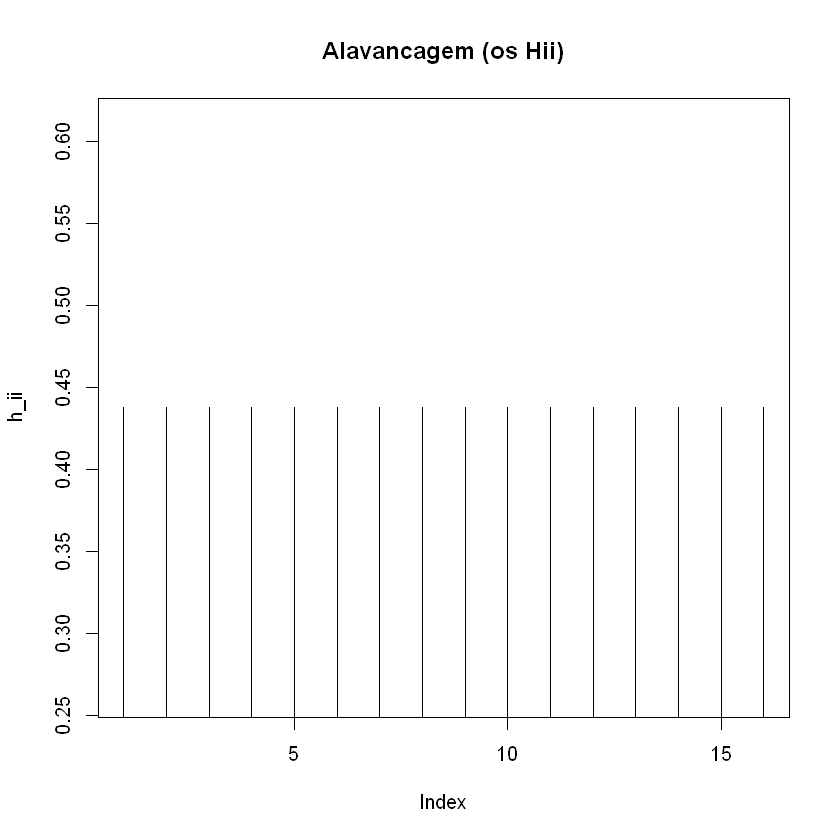

   obs Taxa Forno Tamanho ajustado resid_ord    hii  resid_stud   resid_del
1    1    5     1       8  11.3125   -3.3125 0.4375 -1.49966636 -1.63250892
2    2   10     1      14  14.0625   -0.0625 0.4375 -0.02829559 -0.02667853
3    3   15     1      14  13.3125    0.6875 0.4375  0.31125151  0.29504298
4    4   20     1      17  14.3125    2.6875 0.4375  1.21671045  1.25497307
5    5    5     2       4   4.0625   -0.0625 0.4375 -0.02829559 -0.02667853
6    6   10     2       5   6.8125   -1.8125 0.4375 -0.82057216 -0.80431528
7    7   15     2       6   6.0625   -0.0625 0.4375 -0.02829559 -0.02667853
8    8   20     2       9   7.0625    1.9375 0.4375  0.87716334  0.86478895
9    9    5     3       5   3.8125    1.1875 0.4375  0.53761624  0.51520984
10  10   10     3       6   6.5625   -0.5625 0.4375 -0.25466033 -0.24096580
11  11   15     3       9   5.8125    3.1875 0.4375  1.44307518  1.55188058
12  12   20     3       3   6.8125   -3.8125 0.4375 -1.72603110 -1.98960062
13  13    5 

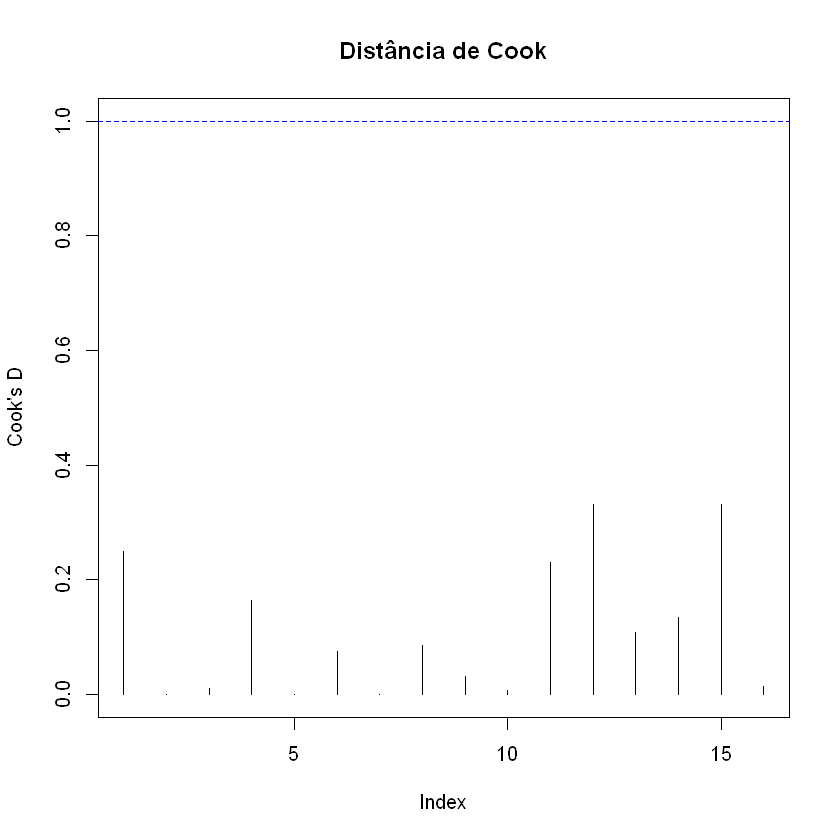

named integer(0)

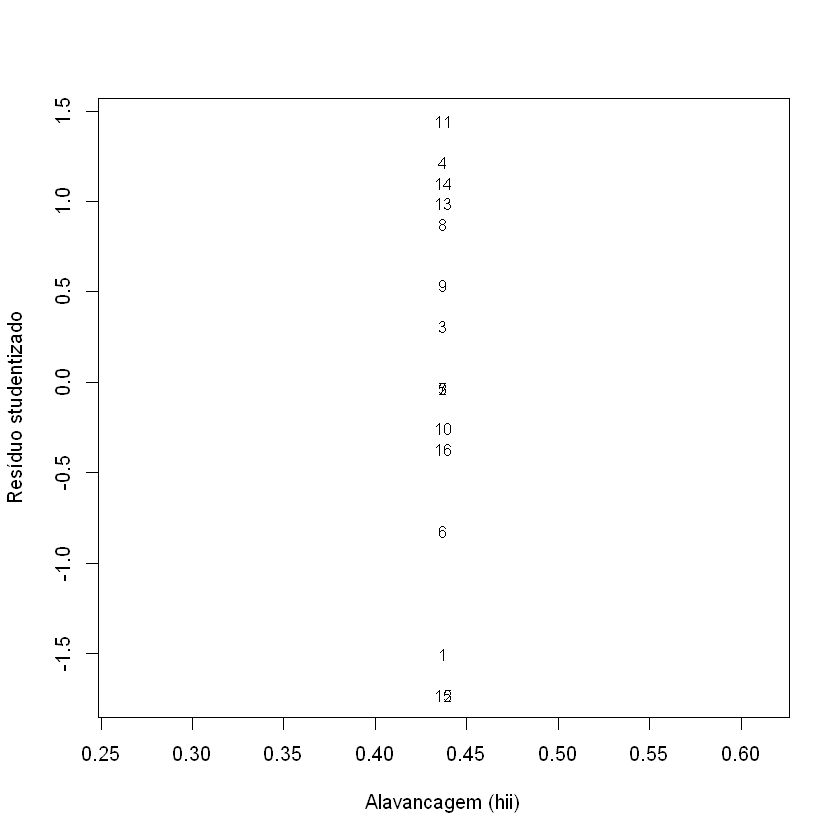

In [10]:
# Matriz chapéu e alavancagem
X <- model.matrix(mod_reg_dummy)
H <- X %*% solve(t(X) %*% X) %*% t(X)
hii <- diag(H)

# Limiar de alavancagem (2p/n)
p <- length(coef(mod_reg_dummy))
n <- nrow(dados_dummy)
limiar <- 2*p/n

plot(hii, type = "h", col = ifelse(hii > limiar, "red", "black"),
     main = "Alavancagem (os Hii)", ylab = "h_ii")
abline(h = limiar, lty = 2, col = "blue")

# Resíduos ordinários, studentizados internos e externos
res_ord <- residuals(mod_reg_dummy)
res_stud <- rstandard(mod_reg_dummy)   # studentizado interno
res_del <- rstudent(mod_reg_dummy)     # studentizado externo (deletado)

# Distância de Cook
cook <- cooks.distance(mod_reg_dummy)
limiar_cook <- 4 / nrow(dados)   # regra: se maior que 4/n
limiar_cook <- 1
plot(cook, type = "h",ylim = c(0, 1), col = ifelse(cook > limiar_cook, "red", "black"),
     main = "Distância de Cook", ylab = "Cook's D")
abline(h = limiar_cook, lty = 2, col = "blue")
# Juntar numa tabela para inspeção

diagnostico <- data.frame(
  obs = 1:n,
  Taxa = dados$Taxa,
  Forno = dados$Forno,
  Tamanho = dados$Tamanho,
  ajustado = fitted(mod_reg_dummy),
  resid_ord = res_ord,
  hii = hii,
  resid_stud = res_stud,
  resid_del = res_del,
  cook = cook
)

# Identificar possíveis outliers (|resid_del| > 2) e alta alavancagem (hii > limiar)
diagnostico$outlier <- abs(diagnostico$resid_del) > 2
diagnostico$alta_alav <- diagnostico$hii > limiar

# Visualizar
print(diagnostico)

# Gráfico de alavancagem vs resíduo studentizado
plot(hii, res_stud, type = "n", xlab = "Alavancagem (hii)", ylab = "Resíduo studentizado")
text(hii, res_stud, labels = 1:n, cex = 0.8)
abline(v = limiar, col = "red", lty = 2)
abline(h = c(-2, 2), col = "blue", lty = 2)

# Identificar observações com Cook > 1 (se houver)
which(cook > 1)

## 3. Comparação entre as abordagens

As duas abordagens levaram a mesma conclusão: A
hipótese nula não é rejeitada. Os dados não oferecem evidências suficientes para concluir que a taxa de agitação (o fator de interesse) apresenta efeito diferente no tamanho do grão produzido.